# ABC Model

A three-variable ODE with:
- **Negative feedback loop** between A and B (integral feedback)
- **Tumor dynamics** driven by B

## Equations

$$\frac{dA}{dt} = a_1(\mu - B)$$

$$\frac{dB}{dt} = b_1 A - b_2 B$$

$$\frac{dC}{dt} = C\bigl(c_1 - c_2 \max(\mu - B,\, 0)\bigr)$$

**Interpretation:**
- $A$: compensatory adaptation
- $B$: cancer-supporting TME component (setpoint $\mu$)
- $C$: tumor size

**Topology:**
- $A$ activates $B$ (via $b_1 A$); $B$ inhibits $A$ (integral feedback) → $B_{ss} = \mu$
- Tumor grows at rate $c_1$; removal $c_2 \max(\mu-B, 0)$ is only active when $B < \mu$
- Treatment reduces $b_1$, pushing $B$ below $\mu$ and enabling tumor removal

**Steady states (off treatment):**
$$B_{ss} = \mu, \quad A_{ss} = \frac{b_2\,\mu}{b_1}$$

Off treatment: $B = \mu$ so $\max(\mu-B,0)=0$ and tumor grows at rate $c_1$.  
On treatment: $B < \mu$ and tumor removal $c_2(\mu-B)$ can overcome growth.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [3]:
# ======================================================================
# Parameters
# ======================================================================

mu = 1.0

# AB parameters
a1 = 1.0
b1 = 1.0   # A → B activation (halved by treatment)
b2 = 2.0

# C parameters
c1 = 0.1   # tumor growth rate
c2 = 1.0   # tumor removal rate (active when B < mu)

# Off-treatment steady states (B=mu by integral feedback)
B_ss = mu
A_ss = b2 * mu / b1

print(f"Off-treatment steady state: A={A_ss:.2f}, B={B_ss:.2f}")
print(f"Off-treatment: tumor grows at rate c1={c1} (no removal since B=mu)")

# Treatment: halve b1
b1_on = b1 / 2
A_ss_on = b2 * mu / b1_on
print(f"\nOn-treatment steady state (AB): A={A_ss_on:.2f}, B={B_ss:.2f}")
print(f"On-treatment: B transiently dips below mu → tumor removal active")

Off-treatment steady state: A=2.00, B=1.00
Off-treatment: tumor grows at rate c1=0.1 (no removal since B=mu)

On-treatment steady state (AB): A=4.00, B=1.00
On-treatment: B transiently dips below mu → tumor removal active


In [4]:
# ======================================================================
# ODE definition
# ======================================================================

def abc_rhs(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0))
    return [dA, dB, dC]

In [5]:
# ======================================================================
# Simulation: start at off-treatment SS, apply treatment, then release
# ======================================================================

from scipy.integrate import odeint

# Initial condition: off-treatment steady state, tumor at C=1
y0 = [A_ss, B_ss, 1.0]

t_treatment = 10.0   # apply treatment at t=0, release at t=10
t_end       = 30.0   # end simulation at t=30

t1 = np.linspace(0, t_treatment, 300)
t2 = np.linspace(0, t_end - t_treatment, 600)

# Phase 1: on treatment (b1 halved)
sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), y0, t1)
A1, B1, C1 = sol1.T

# Phase 2: off treatment (b1 restored)
sol2 = odeint(lambda y, t: abc_rhs(t, y, b1), sol1[-1], t2)
A2, B2, C2 = sol2.T

t_full = np.concatenate([t1, t_treatment + t2[1:]])
A_full = np.concatenate([A1, A2[1:]])
B_full = np.concatenate([B1, B2[1:]])
C_full = np.concatenate([C1, C2[1:]])

print("Simulation complete.")
print(f"  Final state: A={A_full[-1]:.3f}, B={B_full[-1]:.3f}, C={C_full[-1]:.3f}")

Simulation complete.
  Final state: A=2.000, B=1.000, C=3.092


/tmp/ipykernel_1656465/2918764802.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


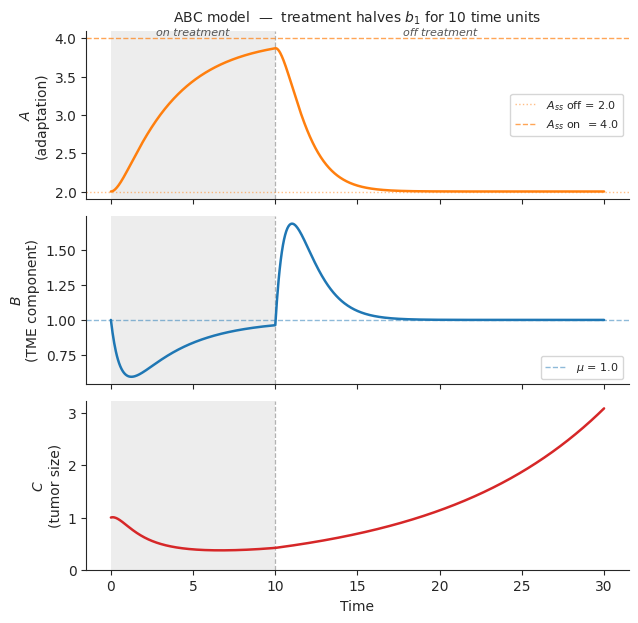

In [6]:
# ======================================================================
# Plot
# ======================================================================

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

for ax in axes:
    ax.axvspan(0, t_treatment, color='lightgray', alpha=0.4, lw=0, zorder=0)
    ax.axvline(t_treatment, color='gray', ls='--', lw=0.9, alpha=0.6)
    clean_ax(ax)

axes[0].plot(t_full, A_full, color='C1', lw=1.8)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='center right')

axes[1].plot(t_full, B_full, color='C0', lw=1.8)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_full, C_full, color='C3', lw=1.8)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

trans = axes[0].get_xaxis_transform()
kw = dict(ha='center', va='bottom', fontsize=8, color='#555555', fontstyle='italic', transform=trans)
axes[0].text(t_treatment / 2,                     0.96, 'on treatment', **kw)
axes[0].text((t_treatment + t_end) / 2,           0.96, 'off treatment', **kw)

axes[0].set_title(f'ABC model  —  treatment halves $b_1$ for {int(t_treatment)} time units', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_treatment.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1656465/4203207906.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


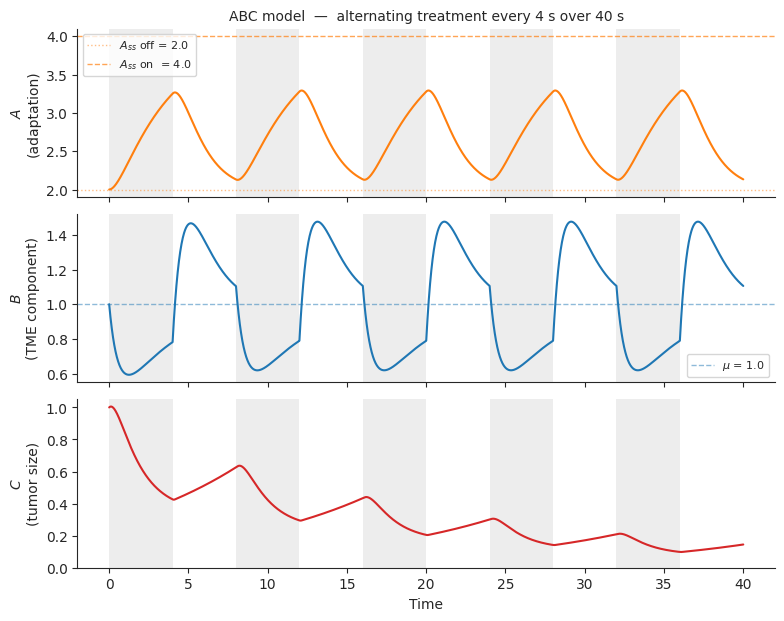

In [7]:
# ======================================================================
# Alternating treatment: switch every 4 seconds for 40 seconds total
# ======================================================================

t_switch = 4.0
t_total  = 40.0
n_cycles = int(t_total / t_switch)

t_all = []
A_all = []
B_all = []
C_all = []

y_cur = [A_ss, B_ss, 1.0]   # start at off-treatment SS
t_cur = 0.0

for i in range(n_cycles):
    b1_cur = b1_on if (i % 2 == 0) else b1   # start on treatment
    t_seg = np.linspace(0, t_switch, 200)
    sol = odeint(lambda y, t: abc_rhs(t, y, b1_cur), y_cur, t_seg)
    t_all.append(t_cur + t_seg)
    A_all.append(sol[:, 0])
    B_all.append(sol[:, 1])
    C_all.append(sol[:, 2])
    t_cur += t_switch
    y_cur = sol[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

# shade treatment periods (even cycles)
for i in range(n_cycles):
    if i % 2 == 0:
        for ax in axes:
            ax.axvspan(i * t_switch, (i + 1) * t_switch,
                       color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(f'ABC model  —  alternating treatment every {t_switch:.0f} s over {t_total:.0f} s', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_cycling.pdf', bbox_inches='tight')
plt.show()

# Analytical Analysis of the ABC Model

## Tumor shrinkage condition

Since $C > 0$, we can divide $\dot{C} = C(c_1 - c_2(\mu-B)^+)$ by $C$ and integrate:

$$\ln\frac{C(T)}{C(0)} = c_1 T - c_2 \int_0^T (\mu - B)^+\, dt$$

For tumor shrinkage over $[0, T]$ we need $C(T) < C(0)$, i.e. the left side $< 0$:

$$\boxed{\frac{c_1}{c_2} < \frac{1}{T}\int_0^T (\mu - B)^+\, dt}$$

The **time-averaged dip of $B$ below $\mu$** must exceed $c_1/c_2$.

Treatment works by pushing $B$ below $\mu$; integral feedback then drives $B$ back, but by how much and for how long depends on $b_1$, $b_2$, $a_1$.

## AB subsystem — eigenvalue analysis

The $(A, B)$ dynamics linearize around any point as:

$$J = \begin{pmatrix} 0 & -a_1 \\ b_1 & -b_2 \end{pmatrix}, \qquad \lambda_{1,2} = \frac{-b_2 \pm \sqrt{b_2^2 - 4\,a_1 b_1}}{2}$$

Both eigenvalues always have negative real part (stable), since $a_1, b_1, b_2 > 0$.

**Note:** with the default parameters ($a_1=1, b_1=1, b_2=2$), $b_2^2 - 4a_1b_1 = 0$ exactly, so the off-treatment system is *critically damped* — a coincidence of the chosen parameters, not a general property.

In [8]:
import sympy as sp

t_s = sp.Symbol('t', real=True, positive=True)
a1_s, b1_s, b2_s, mu_s = sp.symbols('a1 b1 b2 mu', positive=True)

# Jacobian
J = sp.Matrix([[0, -a1_s], [b1_s, -b2_s]])
eigs = J.eigenvals()
lam = list(eigs.keys())
print("General eigenvalues:")
for l in lam:
    print(" ", sp.simplify(l))

# Evaluate for our two parameter sets
p_off = {a1_s: a1, b1_s: b1,    b2_s: b2, mu_s: mu}
p_on  = {a1_s: a1, b1_s: b1_on, b2_s: b2, mu_s: mu}

lam_off = sorted([complex(l.subs(p_off)) for l in lam], key=lambda x: x.real)
lam_on  = sorted([complex(l.subs(p_on))  for l in lam], key=lambda x: x.real)

print(f"\nOff-treatment eigenvalues: {[f'{l.real:.4f}' for l in lam_off]}")
print(f"On-treatment  eigenvalues: {[f'{l.real:.4f}' for l in lam_on]}")

# Recovery time constant from the dominant (slowest) eigenvalue off-treatment
dom_eig_off = max(lam_off, key=lambda x: x.real)
tau = 1.0 / abs(dom_eig_off.real)
print(f"\nDominant off-treatment eigenvalue: {dom_eig_off.real:.4f}")
print(f"Time constant τ = {tau:.2f}")
print(f"95% recovery ≈ 3τ = {3*tau:.2f}")
print(f"99% recovery ≈ 4.6τ = {4.6*tau:.2f}")
print(f"(These are approximate — critically damped system has te^(-t) terms)")

# Shrinkage condition threshold for current parameters
print(f"\nShrinkage condition threshold  c1/c2 = {c1/c2:.4f}")
print(f"Treatment must maintain  avg[(mu-B)+] > {c1/c2:.4f}  over the treatment window")

General eigenvalues:
  -b2/2 - sqrt(-4*a1*b1 + b2**2)/2
  -b2/2 + sqrt(-4*a1*b1 + b2**2)/2

Off-treatment eigenvalues: ['-1.0000', '-1.0000']
On-treatment  eigenvalues: ['-1.7071', '-0.2929']

Dominant off-treatment eigenvalue: -1.0000
Time constant τ = 1.00
95% recovery ≈ 3τ = 3.00
99% recovery ≈ 4.6τ = 4.60
(These are approximate — critically damped system has te^(-t) terms)

Shrinkage condition threshold  c1/c2 = 0.1000
Treatment must maintain  avg[(mu-B)+] > 0.1000  over the treatment window


## Closed-Form Solution for $A(t)$ and $B(t)$ During Treatment

### Setup

Before treatment ($t < 0$) the system rests at its off-treatment steady state:

$$A(0) = \frac{b_2\,\mu}{b_{1,\text{off}}}, \qquad B(0) = \mu$$

During the on-treatment phase $0 \le t \le T_1$ the ODEs are:

$$\dot{A} = a_1(\mu - B), \qquad \dot{B} = b_{1,\text{on}}\,A - b_2\,B$$

### Reduction to a Single Second-Order ODE for $B$

Differentiate the $\dot{B}$ equation and substitute $\dot{A}$:

$$\ddot{B} = b_{1,\text{on}}\,\dot{A} - b_2\,\dot{B} = b_{1,\text{on}}\,a_1(\mu - B) - b_2\,\dot{B}$$

Rearranging:

$$\ddot{B} + b_2\,\dot{B} + a_1\,b_{1,\text{on}}\,B = a_1\,b_{1,\text{on}}\,\mu$$

### Solution

**Particular solution** (set derivatives to zero): $B_p = \mu$.

**Homogeneous solution**: characteristic roots

$$\lambda_{1,2} = \frac{-b_2 \pm \sqrt{b_2^2 - 4\,a_1\,b_{1,\text{on}}}}{2}$$

**General solution:**

$$B(t) = \mu + K_1 e^{\lambda_1 t} + K_2 e^{\lambda_2 t}$$

### Applying Initial Conditions

From $B(0) = \mu$: $K_1 + K_2 = 0 \;\Rightarrow\; K_2 = -K_1$.

From $\dot{B}(0) = b_{1,\text{on}}\,A(0) - b_2\,B(0) = b_2\,\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)$:

$$K_1(\lambda_1 - \lambda_2) = b_2\,\mu\!\left(\frac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)
\;\Rightarrow\;
K_1 = \frac{b_2\,\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)}{\lambda_1 - \lambda_2}$$

So:

$$\boxed{B(t) = \mu + K_1\!\left(e^{\lambda_1 t} - e^{\lambda_2 t}\right)}$$

### Recovering $A(t)$

Rearrange $\dot{B} = b_{1,\text{on}}\,A - b_2\,B$:

$$\boxed{A(t) = \frac{\dot{B}(t) + b_2\,B(t)}{b_{1,\text{on}}}}$$

λ₁ = -b2/2 + sqrt(-4*a1*b1_on + b2**2)/2
λ₂ = -b2/2 - sqrt(-4*a1*b1_on + b2**2)/2

K₁ = b2*mu*(-b1_off + b1_on)/(b1_off*sqrt(-4*a1*b1_on + b2**2))

B(t) = K1*(exp(lambda1*t) - exp(lambda2*t)) + mu
A(t) = (K1*(lambda1*exp(lambda1*t) - lambda2*exp(lambda2*t)) + b2*(K1*(exp(lambda1*t) - exp(lambda2*t)) + mu))/b1_on

── Verification at t=0 ──
B(0) = mu   (expected μ)
A(0) = 0   (A(0) - b2μ/b1_off, expected 0)

── Numerical values (a1=1.0, b1_on=0.5, b1_off=1.0, b2=2.0, μ=1.0) ──
λ₁ = -0.2929
λ₂ = -1.7071
K₁ = -0.7071
B(t) = 1.0 + -0.7071*(exp(-0.2929*t) - exp(-1.7071*t))


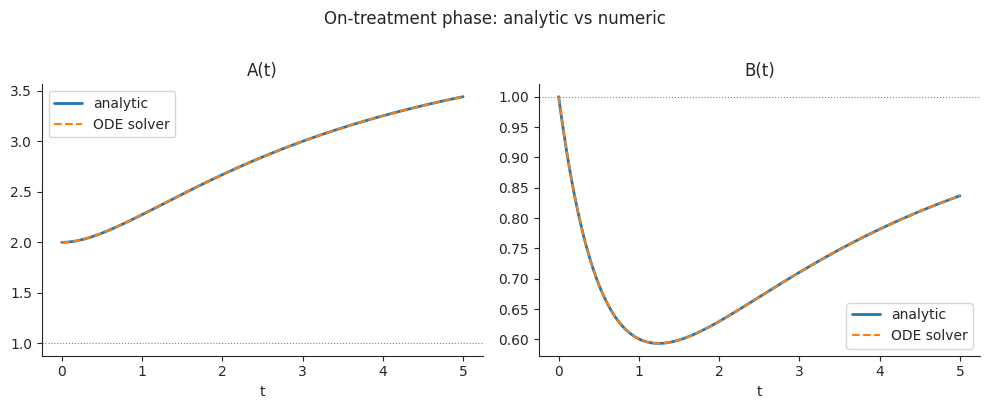


Max |analytic - ODE| over [0, T1=5.0]:  A: 2.03e-07,  B: 3.47e-07


In [9]:
import sympy as sp

# ── Symbols ───────────────────────────────────────────────────────────────────
t_s = sp.Symbol('t', real=True, nonnegative=True)
a1_s, b1on_s, b1off_s, b2_s, mu_s = sp.symbols(
    'a1 b1_on b1_off b2 mu', positive=True)
lam1_s, lam2_s, K1_s = sp.symbols('lambda1 lambda2 K1', real=True)

# ── Eigenvalues (characteristic roots) ────────────────────────────────────────
disc = b2_s**2 - 4*a1_s*b1on_s
lam1_expr = (-b2_s + sp.sqrt(disc)) / 2
lam2_expr = (-b2_s - sp.sqrt(disc)) / 2
print("λ₁ =", lam1_expr)
print("λ₂ =", lam2_expr)

# ── Constant K1 ───────────────────────────────────────────────────────────────
dB0 = b2_s * mu_s * (b1on_s/b1off_s - 1)          # dB/dt at t=0
K1_expr = dB0 / (lam1_expr - lam2_expr)
K1_expr = sp.simplify(K1_expr)
print("\nK₁ =", K1_expr)

# ── B(t) ──────────────────────────────────────────────────────────────────────
B_expr = mu_s + K1_s*(sp.exp(lam1_s*t_s) - sp.exp(lam2_s*t_s))
print("\nB(t) =", B_expr)

# ── A(t)  via  A = (dB/dt + b2*B) / b1_on ────────────────────────────────────
dBdt_expr = sp.diff(B_expr, t_s)
A_expr = sp.simplify((dBdt_expr + b2_s*B_expr) / b1on_s)
print("A(t) =", A_expr)

# ── Verify initial conditions symbolically ────────────────────────────────────
# Substitute K1, lam1, lam2 as their expressions (drop the placeholder symbols)
subs_dict = {K1_s: K1_expr, lam1_s: lam1_expr, lam2_s: lam2_expr}

B0_check = sp.simplify(B_expr.subs(subs_dict).subs(t_s, 0))
A0_check = sp.simplify(A_expr.subs(subs_dict).subs(t_s, 0))
A0_expected = b2_s*mu_s/b1off_s

print("\n── Verification at t=0 ──")
print("B(0) =", B0_check, "  (expected μ)")
print("A(0) =", sp.simplify(A0_check - A0_expected), "  (A(0) - b2μ/b1_off, expected 0)")

# ── Numerical evaluation with model parameters ────────────────────────────────
num_subs = {a1_s: a1, b1on_s: b1_on, b1off_s: b1, b2_s: b2, mu_s: mu}

lam1_num = float(lam1_expr.subs(num_subs))
lam2_num = float(lam2_expr.subs(num_subs))
K1_num   = float(K1_expr.subs(num_subs))

print(f"\n── Numerical values (a1={a1}, b1_on={b1_on}, b1_off={b1}, b2={b2}, μ={mu}) ──")
print(f"λ₁ = {lam1_num:.4f}")
print(f"λ₂ = {lam2_num:.4f}")
print(f"K₁ = {K1_num:.4f}")
print(f"B(t) = {mu} + {K1_num:.4f}*(exp({lam1_num:.4f}*t) - exp({lam2_num:.4f}*t))")

# ── Quick plot: compare analytic vs numeric ODE ───────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

T1 = 5.0
t_plot = np.linspace(0, T1, 300)

B_analytic = mu + K1_num*(np.exp(lam1_num*t_plot) - np.exp(lam2_num*t_plot))
dB_analytic = K1_num*(lam1_num*np.exp(lam1_num*t_plot) - lam2_num*np.exp(lam2_num*t_plot))
A_analytic  = (dB_analytic + b2*B_analytic) / b1_on

def ode(t, y):
    A, B = y
    return [a1*(mu - B), b1_on*A - b2*B]

sol = solve_ivp(ode, [0, T1], [b2*mu/b1, mu], t_eval=t_plot, rtol=1e-9)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, analytic, numeric, label in zip(
        axes,
        [A_analytic, B_analytic],
        [sol.y[0], sol.y[1]],
        ['A(t)', 'B(t)']):
    ax.plot(t_plot, analytic, lw=2, label='analytic')
    ax.plot(t_plot, numeric, '--', lw=1.5, label='ODE solver')
    ax.axhline(mu, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('t')
    ax.set_title(label)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('On-treatment phase: analytic vs numeric', y=1.01)
plt.tight_layout()
plt.show()

max_err_A = np.max(np.abs(A_analytic - sol.y[0]))
max_err_B = np.max(np.abs(B_analytic - sol.y[1]))
print(f"\nMax |analytic - ODE| over [0, T1={T1}]:  A: {max_err_A:.2e},  B: {max_err_B:.2e}")

## Closed-Form Solution for $A(\tau)$ and $B(\tau)$ During Recovery (Off-Treatment)

Let $\tau = t - T_1$ be the time since treatment ended. The off-treatment phase covers $0 \le \tau \le T_2$.

### Handoff Initial Conditions

The starting values are the on-treatment solutions evaluated at $T_1$:
$$A_1 = A_{\text{on}}(T_1), \qquad B_1 = B_{\text{on}}(T_1)$$

### Off-Treatment ODE System

With $b_{1,\text{off}}$ restored:
$$\dot{A} = a_1(\mu - B), \qquad \dot{B} = b_{1,\text{off}}\,A - b_2\,B$$

The same reduction as before gives:
$$\ddot{B} + b_2\,\dot{B} + a_1\,b_{1,\text{off}}\,B = a_1\,b_{1,\text{off}}\,\mu$$

### General Solution (Distinct Roots)

New characteristic roots (distinct from $\lambda_{1,2}$):
$$\gamma_{1,2} = \frac{-b_2 \pm \sqrt{b_2^2 - 4\,a_1\,b_{1,\text{off}}}}{2}$$

$$B_{\text{off}}(\tau) = \mu + C_1 e^{\gamma_1\tau} + C_2 e^{\gamma_2\tau}$$

### Solving for $C_1$ and $C_2$

Two equations from the initial conditions at $\tau=0$:

$$C_1 + C_2 = B_1 - \mu$$
$$C_1\gamma_1 + C_2\gamma_2 = b_{1,\text{off}}\,A_1 - b_2\,B_1$$

Solving:

$$\boxed{C_1 = \frac{b_{1,\text{off}}\,A_1 - b_2\,B_1 - \gamma_2(B_1 - \mu)}{\gamma_1 - \gamma_2}, \qquad
C_2 = \frac{b_{1,\text{off}}\,A_1 - b_2\,B_1 - \gamma_1(B_1 - \mu)}{\gamma_2 - \gamma_1}}$$

And $A_{\text{off}}$ follows from rearranging $\dot{B} = b_{1,\text{off}}\,A - b_2\,B$:

$$\boxed{A_{\text{off}}(\tau) = \frac{\dot{B}_{\text{off}}(\tau) + b_2\,B_{\text{off}}(\tau)}{b_{1,\text{off}}}}$$

> **Critical note:** With default parameters $a_1=1,\ b_{1,\text{off}}=1,\ b_2=2$ the discriminant is $b_2^2 - 4a_1 b_{1,\text{off}} = 0$, giving a **repeated root** $\gamma = -b_2/2$. The two-root formula above has $\gamma_1 - \gamma_2$ in the denominator and is undefined. The correct repeated-root solution is:
> $$B_{\text{off}}(\tau) = \mu + (C_1 + C_2\,\tau)\,e^{\gamma\tau}$$
> with $C_1 = B_1 - \mu$ and $C_2 = b_{1,\text{off}}\,A_1 - b_2\,B_1 - \gamma(B_1 - \mu)$.

γ₁ = -b2/2 + sqrt(-4*a1*b1_off + b2**2)/2
γ₂ = -b2/2 - sqrt(-4*a1*b1_off + b2**2)/2

C₁ = (A1*b1_off - B1*b2 - B1*gamma2 + gamma2*mu)/(gamma1 - gamma2)
C₂ = (-A1*b1_off + B1*b2 + B1*gamma1 - gamma1*mu)/(gamma1 - gamma2)

C₁ matches textbook: True
C₂ matches textbook: True

── Symbolic verification at τ=0 ──
B_off(0) - B1 = 0
A_off(0) - A1 = 0

Handoff at T1=5.0:  B1=0.836655,  A1=3.441912

Off-treatment discriminant = 0.0000  → REPEATED ROOT  (using B_off = μ + (C1 + C2·τ)·e^{γτ})
γ = -1.0000,  C1 = -0.163345,  C2 = 1.605257


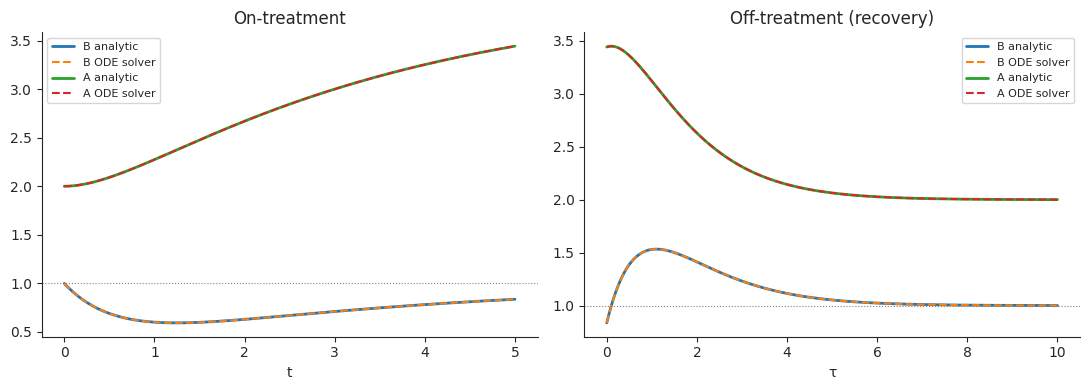


Max |analytic - ODE| over off-treatment phase [0, T2=10.0]:
  A: 3.10e-07
  B: 2.93e-07


In [10]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Symbols (keep consistent with on-treatment cell) ──────────────────────────
tau_s = sp.Symbol('tau', nonneg=True)
a1_s, b1on_s, b1off_s, b2_s, mu_s = sp.symbols('a1 b1_on b1_off b2 mu', positive=True)
gam1_s, gam2_s = sp.symbols('gamma1 gamma2', real=True)
C1_s, C2_s     = sp.symbols('C1 C2', real=True)
A1_s, B1_s     = sp.symbols('A1 B1', real=True)   # handoff values (treated as constants here)

# ── Off-treatment eigenvalues ─────────────────────────────────────────────────
disc_off  = b2_s**2 - 4*a1_s*b1off_s
gam1_expr = (-b2_s + sp.sqrt(disc_off)) / 2
gam2_expr = (-b2_s - sp.sqrt(disc_off)) / 2
print("γ₁ =", gam1_expr)
print("γ₂ =", gam2_expr)

# ── General B_off (distinct-root form) ───────────────────────────────────────
B_off = mu_s + C1_s*sp.exp(gam1_s*tau_s) + C2_s*sp.exp(gam2_s*tau_s)

# ── Solve for C1, C2 from initial conditions ─────────────────────────────────
IC_B  = sp.Eq(B_off.subs(tau_s, 0), B1_s)
IC_dB = sp.Eq(sp.diff(B_off, tau_s).subs(tau_s, 0), b1off_s*A1_s - b2_s*B1_s)

sol_C = sp.solve([IC_B, IC_dB], [C1_s, C2_s])
C1_formula = sp.simplify(sol_C[C1_s])
C2_formula = sp.simplify(sol_C[C2_s])
print("\nC₁ =", C1_formula)
print("C₂ =", C2_formula)

# ── Verify against the textbook closed-form expressions ───────────────────────
C1_textbook = (b1off_s*A1_s - b2_s*B1_s - gam2_s*(B1_s - mu_s)) / (gam1_s - gam2_s)
C2_textbook = (b1off_s*A1_s - b2_s*B1_s - gam1_s*(B1_s - mu_s)) / (gam2_s - gam1_s)
print("\nC₁ matches textbook:", sp.simplify(C1_formula - C1_textbook) == 0)
print("C₂ matches textbook:", sp.simplify(C2_formula - C2_textbook) == 0)

# ── Build B_off and A_off with solved constants ───────────────────────────────
B_off_sol  = B_off.subs(sol_C)
dBdtau_sol = sp.diff(B_off_sol, tau_s)
A_off_sol  = sp.simplify((dBdtau_sol + b2_s*B_off_sol) / b1off_s)

# ── Verify initial conditions symbolically ────────────────────────────────────
print("\n── Symbolic verification at τ=0 ──")
print("B_off(0) - B1 =", sp.simplify(B_off_sol.subs(tau_s, 0) - B1_s))
print("A_off(0) - A1 =", sp.simplify(A_off_sol.subs(tau_s, 0) - A1_s))

# ── Numerical evaluation ──────────────────────────────────────────────────────
# On-treatment parameters (from parameters cell)
disc_on_num = b2**2 - 4*a1*b1_on           # > 0 → two distinct roots
lam1_num = (-b2 + np.sqrt(disc_on_num)) / 2
lam2_num = (-b2 - np.sqrt(disc_on_num)) / 2
dB0_on   = b2 * mu * (b1_on/b1 - 1)
K1_num   = dB0_on / (lam1_num - lam2_num)

def B_on_num(t):
    return mu + K1_num*(np.exp(lam1_num*t) - np.exp(lam2_num*t))

def dBon_num(t):
    return K1_num*(lam1_num*np.exp(lam1_num*t) - lam2_num*np.exp(lam2_num*t))

def A_on_num(t):
    return (dBon_num(t) + b2*B_on_num(t)) / b1_on

# Handoff values at chosen T1
T1 = 5.0
B1_num = B_on_num(T1)
A1_num = A_on_num(T1)
print(f"\nHandoff at T1={T1}:  B1={B1_num:.6f},  A1={A1_num:.6f}")

# Off-treatment: check discriminant → repeated or distinct root
disc_off_num = b2**2 - 4*a1*b1    # b1 is b1_off
print(f"\nOff-treatment discriminant = {disc_off_num:.4f}  ", end='')

T2 = 10.0

if abs(disc_off_num) < 1e-12:
    # ── Repeated root ─────────────────────────────────────────────────────────
    print("→ REPEATED ROOT  (using B_off = μ + (C1 + C2·τ)·e^{γτ})")
    gam_rep = -b2 / 2
    C1_rep  = B1_num - mu
    C2_rep  = b1*A1_num - b2*B1_num - gam_rep*(B1_num - mu)
    print(f"γ = {gam_rep:.4f},  C1 = {C1_rep:.6f},  C2 = {C2_rep:.6f}")

    def B_off_num(tau):
        return mu + (C1_rep + C2_rep*tau)*np.exp(gam_rep*tau)

    def dBoff_num(tau):
        return (C2_rep + (C1_rep + C2_rep*tau)*gam_rep)*np.exp(gam_rep*tau)

else:
    # ── Distinct roots ────────────────────────────────────────────────────────
    print("→ distinct roots")
    gam1_num = (-b2 + np.sqrt(disc_off_num)) / 2
    gam2_num = (-b2 - np.sqrt(disc_off_num)) / 2
    C1_num   = (b1*A1_num - b2*B1_num - gam2_num*(B1_num - mu)) / (gam1_num - gam2_num)
    C2_num   = (b1*A1_num - b2*B1_num - gam1_num*(B1_num - mu)) / (gam2_num - gam1_num)
    print(f"γ₁={gam1_num:.4f}, γ₂={gam2_num:.4f}, C1={C1_num:.6f}, C2={C2_num:.6f}")

    def B_off_num(tau):
        return mu + C1_num*np.exp(gam1_num*tau) + C2_num*np.exp(gam2_num*tau)

    def dBoff_num(tau):
        return C1_num*gam1_num*np.exp(gam1_num*tau) + C2_num*gam2_num*np.exp(gam2_num*tau)

def A_off_num(tau):
    return (dBoff_num(tau) + b2*B_off_num(tau)) / b1

# ── ODE reference solution for the full cycle ─────────────────────────────────
def ode_on(t, y):
    A, B = y
    return [a1*(mu - B), b1_on*A - b2*B]

def ode_off(t, y):
    A, B = y
    return [a1*(mu - B), b1*A - b2*B]

t_on  = np.linspace(0, T1, 400)
t_off = np.linspace(0, T2, 400)

sol_on  = solve_ivp(ode_on,  [0,  T1], [b2*mu/b1, mu],      t_eval=t_on,  rtol=1e-9)
sol_off = solve_ivp(ode_off, [0,  T2], [A1_num, B1_num],     t_eval=t_off, rtol=1e-9)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, A_an, B_an, A_ode, B_ode, phase, t_ax in [
        (axes[0],
         A_on_num(t_on),  B_on_num(t_on),
         sol_on.y[0],     sol_on.y[1],
         'On-treatment', t_on),
        (axes[1],
         A_off_num(t_off), B_off_num(t_off),
         sol_off.y[0],     sol_off.y[1],
         'Off-treatment (recovery)', t_off)]:
    ax.plot(t_ax, B_an,  lw=2,        label='B analytic')
    ax.plot(t_ax, B_ode, '--', lw=1.5, label='B ODE solver')
    ax.plot(t_ax, A_an,  lw=2,        label='A analytic')
    ax.plot(t_ax, A_ode, '--', lw=1.5, label='A ODE solver')
    ax.axhline(mu, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('τ' if 'Off' in phase else 't')
    ax.set_title(phase)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Error report ──────────────────────────────────────────────────────────────
print(f"\nMax |analytic - ODE| over off-treatment phase [0, T2={T2}]:")
print(f"  A: {np.max(np.abs(A_off_num(t_off) - sol_off.y[0])):.2e}")
print(f"  B: {np.max(np.abs(B_off_num(t_off) - sol_off.y[1])):.2e}")

## Taylor Approximation for Optimal $T_1^*$

The on-treatment contribution to the time-averaged tumor suppression is:

$$f(T_1) = \frac{1}{T_1}\int_0^{T_1}(\mu - B_{\text{on}}(t))\,dt
= \frac{K_1}{T_1}\left[\frac{1-e^{\lambda_1 T_1}}{\lambda_1} - \frac{1-e^{\lambda_2 T_1}}{\lambda_2}\right]$$

Because the optimality condition $f'(T_1)=0$ is transcendental, we expand each bracket with a Maclaurin series:

$$\frac{1-e^{\lambda T_1}}{\lambda} = -T_1 - \frac{\lambda T_1^2}{2} - \frac{\lambda^2 T_1^3}{6} - \frac{\lambda^3 T_1^4}{24} - \cdots$$

The leading $-T_1$ terms cancel, and after dividing by $T_1$:

$$f(T_1) \approx K_1\!\left[\frac{\lambda_2-\lambda_1}{2}\,T_1 + \frac{\lambda_2^2-\lambda_1^2}{6}\,T_1^2 + \frac{\lambda_2^3-\lambda_1^3}{24}\,T_1^3 + \cdots\right]$$

Setting $f'(T_1)=0$ and dividing by $K_1(\lambda_2-\lambda_1)\neq 0$:

$$\frac{1}{2} + \frac{\lambda_1+\lambda_2}{3}\,T_1 + \frac{\lambda_1^2+\lambda_1\lambda_2+\lambda_2^2}{8}\,T_1^2 + \cdots = 0$$

### First-order (linear) approximation
Drop the $T_1^2$ term:

$$\boxed{T_1^* \approx -\frac{3}{2(\lambda_1+\lambda_2)}}$$

### Second-order (quadratic) approximation
Keep the $T_1^2$ term — standard quadratic $AT_1^2 + BT_1 + C = 0$ with

$$A = \frac{\lambda_1^2+\lambda_1\lambda_2+\lambda_2^2}{8},\quad B = \frac{\lambda_1+\lambda_2}{3},\quad C = \tfrac{1}{2}$$

$$\boxed{T_1^* = \frac{-B - \sqrt{B^2-4AC}}{2A}}$$

> **Critical note for these parameters:** By Vieta's formulas $\lambda_1+\lambda_2 = -b_2$ and $\lambda_1\lambda_2 = a_1 b_{1,\text{on}}$, so $A = \tfrac{b_2^2 - a_1 b_{1,\text{on}}}{8}$, $B = -\tfrac{b_2}{3}$, $C = \tfrac{1}{2}$. With $a_1=1,\,b_{1,\text{on}}=0.5,\,b_2=2$: $B^2-4AC = \tfrac{4}{9}-\tfrac{7}{8} = -\tfrac{31}{72} < 0$ — **no real solution**. This means the quadratic approximation of $f'$ has no zero; the Taylor expansion is not valid out to the true $T_1^*$ and only the first-order formula applies here.

Taylor series of (1-exp(λT1))/λ:
  -T1 - T1**2*lambda/2 - T1**3*lambda**2/6 - T1**4*lambda**3/24 - T1**5*lambda**4/120 + O(T1**6)

f(T1) / K1  ≈ (Taylor, after dividing by T1):
  T1**4*(-lambda1**4/120 + lambda2**4/120) + T1**3*(-lambda1**3/24 + lambda2**3/24) + T1**2*(-lambda1**2/6 + lambda2**2/6) + T1*(-lambda1/2 + lambda2/2)

f'(T1) / K1  ≈
  T1**3*(-lambda1**4/30 + lambda2**4/30) + T1**2*(-lambda1**3/8 + lambda2**3/8) + T1*(-lambda1**2/3 + lambda2**2/3) - lambda1/2 + lambda2/2

First-order T1* = -3/(2*(lambda1 + lambda2))

Quadratic coefficients:  A = lambda1**2/8 + lambda1*lambda2/8 + lambda2**2/8 , B = lambda1/3 + lambda2/3 , C = 1/2
Discriminant = -5*lambda1**2/36 - lambda1*lambda2/36 - 5*lambda2**2/36

── Numerical (λ₁=-0.2929, λ₂=-1.7071, K₁=-0.7071) ──
First-order T1*  = 0.7500
Second-order discriminant = -0.430556  → NO REAL SOLUTION (Taylor expansion invalid at true T1*)
Exact numerical T1*= 2.4025


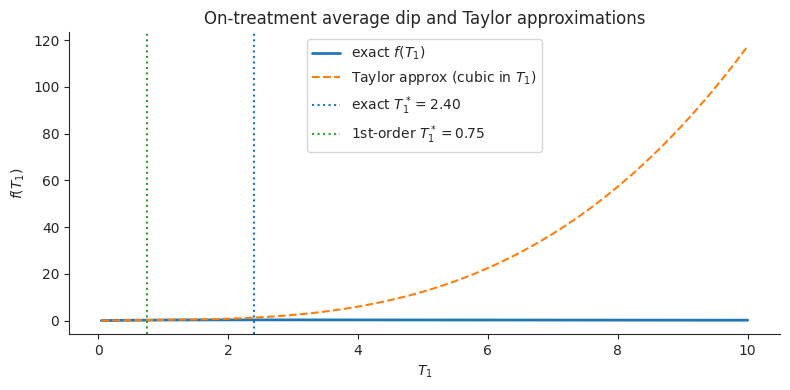


Summary:
  Exact numerical: T1* = 2.4025
  1st-order approx:T1* = 0.7500  (error 1.6525)
  2nd-order approx: no real solution for these parameters


In [11]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# ── Sympy: verify Taylor expansion and derive approximation formulas ──────────
T1_s = sp.Symbol('T1', positive=True)
lam_s = sp.Symbol('lambda', real=True, negative=True)
K1_s, lam1_s, lam2_s = sp.symbols('K1 lambda1 lambda2', real=True)

# Each bracket term in f(T1)
bracket = (1 - sp.exp(lam_s*T1_s)) / lam_s
bracket_series = sp.series(bracket, T1_s, 0, n=6)
print("Taylor series of (1-exp(λT1))/λ:")
print(" ", bracket_series)

# f(T1) = K1/T1 * [bracket(λ1) - bracket(λ2)], expand to order T1^4
bracket1 = sp.series((1 - sp.exp(lam1_s*T1_s))/lam1_s, T1_s, 0, n=6)
bracket2 = sp.series((1 - sp.exp(lam2_s*T1_s))/lam2_s, T1_s, 0, n=6)
diff_series = sp.expand(bracket1 - bracket2)   # leading -T1 cancels
f_series = sp.simplify(diff_series / T1_s)     # divide by T1
f_series = sp.series(f_series.removeO(), T1_s, 0, n=5)
print("\nf(T1) / K1  ≈ (Taylor, after dividing by T1):")
print(" ", f_series)

# Derivative f'(T1)/K1 (set to 0 for optimum)
df_series = sp.diff(f_series, T1_s)
print("\nf'(T1) / K1  ≈")
print(" ", sp.collect(sp.expand(df_series), T1_s))

# ── First-order approximation ─────────────────────────────────────────────────
# Keep only linear term: (λ2-λ1)/2 + (λ2²-λ1²)/3 * T1 = 0
# → T1* = -3 / (2*(λ1+λ2))
T1_1st = sp.Rational(-3, 2) / (lam1_s + lam2_s)
print("\nFirst-order T1* =", T1_1st)

# ── Second-order approximation ────────────────────────────────────────────────
# AT1² + BT1 + C = 0  (after dividing df_series by K1*(λ2-λ1))
A_coef = (lam1_s**2 + lam1_s*lam2_s + lam2_s**2) / 8
B_coef = (lam1_s + lam2_s) / 3
C_coef = sp.Rational(1, 2)
disc_2nd = B_coef**2 - 4*A_coef*C_coef
disc_2nd = sp.simplify(disc_2nd)
print("\nQuadratic coefficients:  A =", A_coef, ", B =", B_coef, ", C =", C_coef)
print("Discriminant =", disc_2nd)
T1_2nd_plus  = (-B_coef + sp.sqrt(disc_2nd)) / (2*A_coef)
T1_2nd_minus = (-B_coef - sp.sqrt(disc_2nd)) / (2*A_coef)

# ── Numerical evaluation for ABC model parameters ─────────────────────────────
disc_on_num = b2**2 - 4*a1*b1_on
lam1_num = (-b2 + np.sqrt(disc_on_num)) / 2
lam2_num = (-b2 - np.sqrt(disc_on_num)) / 2
dB0_on   = b2 * mu * (b1_on/b1 - 1)
K1_num   = dB0_on / (lam1_num - lam2_num)

print(f"\n── Numerical (λ₁={lam1_num:.4f}, λ₂={lam2_num:.4f}, K₁={K1_num:.4f}) ──")

# First-order
T1_1st_num = -3 / (2*(lam1_num + lam2_num))
print(f"First-order T1*  = {T1_1st_num:.4f}")

# Second-order: check discriminant
A_num =  (lam1_num**2 + lam1_num*lam2_num + lam2_num**2) / 8
B_num =  (lam1_num + lam2_num) / 3
C_num =  0.5
disc_num = B_num**2 - 4*A_num*C_num
print(f"Second-order discriminant = {disc_num:.6f}  ", end='')
if disc_num >= 0:
    T1_2nd_p = (-B_num + np.sqrt(disc_num)) / (2*A_num)
    T1_2nd_m = (-B_num - np.sqrt(disc_num)) / (2*A_num)
    # pick the positive root
    T1_2nd_num = T1_2nd_m if T1_2nd_m > 0 else T1_2nd_p
    print(f"→ real roots: +root={T1_2nd_p:.4f}, -root={T1_2nd_m:.4f}")
    print(f"Second-order T1*  = {T1_2nd_num:.4f}  (positive root)")
else:
    T1_2nd_num = None
    print("→ NO REAL SOLUTION (Taylor expansion invalid at true T1*)")

# Exact numerical argmax via scipy
def f_exact(T1):
    return -(K1_num/T1) * ((1 - np.exp(lam1_num*T1))/lam1_num
                           - (1 - np.exp(lam2_num*T1))/lam2_num)

res = minimize_scalar(f_exact, bounds=(0.01, 30), method='bounded')
T1_exact = res.x
print(f"Exact numerical T1*= {T1_exact:.4f}")

# ── Plot f(T1) with the approximations ───────────────────────────────────────
T1_arr = np.linspace(0.05, 10, 500)
f_arr  = (K1_num/T1_arr) * ((1 - np.exp(lam1_num*T1_arr))/lam1_num
                             - (1 - np.exp(lam2_num*T1_arr))/lam2_num)

# Taylor polynomial approximation (degree 3 in T1, i.e. terms up to T1^3)
a1_coef = (lam2_num - lam1_num) / 2
a2_coef = (lam2_num**2 - lam1_num**2) / 6
a3_coef = (lam2_num**3 - lam1_num**3) / 24
f_taylor = K1_num * (a1_coef*T1_arr + a2_coef*T1_arr**2 + a3_coef*T1_arr**3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T1_arr, f_arr,    lw=2,        label='exact $f(T_1)$')
ax.plot(T1_arr, f_taylor, lw=1.5, ls='--', label='Taylor approx (cubic in $T_1$)')
ax.axvline(T1_exact,  color='C0', ls=':', lw=1.5, label=f'exact $T_1^*={T1_exact:.2f}$')
ax.axvline(T1_1st_num, color='C2', ls=':', lw=1.5, label=f'1st-order $T_1^*={T1_1st_num:.2f}$')
if T1_2nd_num is not None:
    ax.axvline(T1_2nd_num, color='C3', ls=':', lw=1.5,
               label=f'2nd-order $T_1^*={T1_2nd_num:.2f}$')
ax.set_xlabel('$T_1$')
ax.set_ylabel('$f(T_1)$')
ax.set_title('On-treatment average dip and Taylor approximations')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Exact numerical: T1* = {T1_exact:.4f}")
print(f"  1st-order approx:T1* = {T1_1st_num:.4f}  (error {abs(T1_1st_num-T1_exact):.4f})")
if T1_2nd_num is not None:
    print(f"  2nd-order approx:T1* = {T1_2nd_num:.4f}  (error {abs(T1_2nd_num-T1_exact):.4f})")
else:
    print("  2nd-order approx: no real solution for these parameters")

Cubic roots: [0.51029156+1.37186012j 0.51029156-1.37186012j 1.16691688+0.j        ]
Real positive roots: [np.float64(1.1669168813762127)]

Summary:
  Exact numerical: T1* = 2.4025
  1st-order:       T1* = 0.7500  (error 1.6525)
  2nd-order:       no real solution
  3rd-order:       T1* = 1.1669  (error 1.2356)


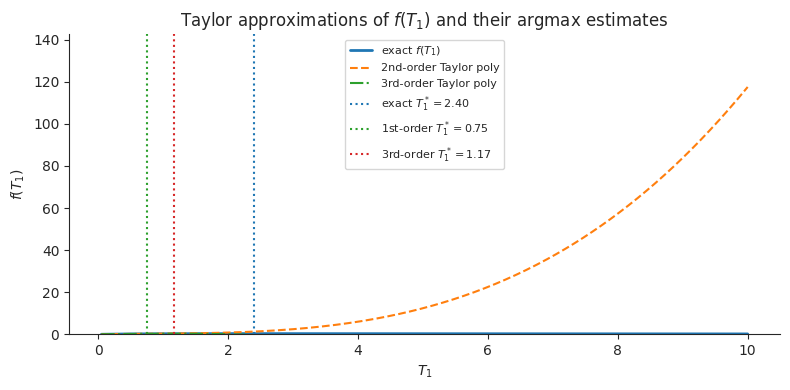

In [12]:
# ── Third-order Taylor approximation for T1* ─────────────────────────────────
# The next term in f'(T1)/K1 comes from the T^4 term of the bracket expansion:
#   (λ2⁴ - λ1⁴)/120 * T1^3  →  after dividing by (λ2-λ1):  (λ1³+λ1²λ2+λ1λ2²+λ2³)/30 * T1³
#
# Full condition to third order (after dividing f'=0 by K1*(λ2-λ1)):
#   D*T1³ + A*T1² + B*T1 + C = 0
#   D = (λ1³+λ1²λ2+λ1λ2²+λ2³)/30
#   A = (λ1²+λ1λ2+λ2²)/8
#   B = (λ1+λ2)/3
#   C = 1/2

import numpy as np
import matplotlib.pyplot as plt

disc_on_num = b2**2 - 4*a1*b1_on
lam1_num = (-b2 + np.sqrt(disc_on_num)) / 2
lam2_num = (-b2 - np.sqrt(disc_on_num)) / 2
dB0_on   = b2 * mu * (b1_on/b1 - 1)
K1_num   = dB0_on / (lam1_num - lam2_num)

D_num = (lam1_num**3 + lam1_num**2*lam2_num + lam1_num*lam2_num**2 + lam2_num**3) / 30
A_num = (lam1_num**2 + lam1_num*lam2_num + lam2_num**2) / 8
B_num = (lam1_num + lam2_num) / 3
C_num = 0.5

# numpy.roots expects coefficients from highest to lowest degree
roots = np.roots([D_num, A_num, B_num, C_num])
print("Cubic roots:", roots)

# Keep only real, positive roots
real_roots = [r.real for r in roots if abs(r.imag) < 1e-10 and r.real > 0]
print("Real positive roots:", real_roots)
T1_3rd_num = real_roots[0] if real_roots else None

# Exact numerical argmax
from scipy.optimize import minimize_scalar

def f_exact(T1):
    return -(K1_num/T1) * ((1 - np.exp(lam1_num*T1))/lam1_num
                           - (1 - np.exp(lam2_num*T1))/lam2_num)

T1_exact = minimize_scalar(f_exact, bounds=(0.01, 30), method='bounded').x

T1_1st_num = -3 / (2*(lam1_num + lam2_num))

print(f"\nSummary:")
print(f"  Exact numerical: T1* = {T1_exact:.4f}")
print(f"  1st-order:       T1* = {T1_1st_num:.4f}  (error {abs(T1_1st_num - T1_exact):.4f})")
print(f"  2nd-order:       no real solution")
if T1_3rd_num:
    print(f"  3rd-order:       T1* = {T1_3rd_num:.4f}  (error {abs(T1_3rd_num - T1_exact):.4f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
T1_arr = np.linspace(0.05, 10, 500)
f_arr  = (K1_num/T1_arr) * ((1 - np.exp(lam1_num*T1_arr))/lam1_num
                             - (1 - np.exp(lam2_num*T1_arr))/lam2_num)

# Taylor polynomials for f(T1) itself (for visual comparison)
a1c = (lam2_num - lam1_num) / 2
a2c = (lam2_num**2 - lam1_num**2) / 6
a3c = (lam2_num**3 - lam1_num**3) / 24
a4c = (lam2_num**4 - lam1_num**4) / 120
f_t2 = K1_num * (a1c*T1_arr + a2c*T1_arr**2 + a3c*T1_arr**3)
f_t3 = K1_num * (a1c*T1_arr + a2c*T1_arr**2 + a3c*T1_arr**3 + a4c*T1_arr**4)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T1_arr, f_arr,  lw=2,              label='exact $f(T_1)$')
ax.plot(T1_arr, f_t2,   lw=1.5, ls='--',  label='2nd-order Taylor poly')
ax.plot(T1_arr, f_t3,   lw=1.5, ls='-.',  label='3rd-order Taylor poly')
ax.axvline(T1_exact,   color='C0', ls=':', lw=1.5, label=f'exact $T_1^*={T1_exact:.2f}$')
ax.axvline(T1_1st_num, color='C2', ls=':', lw=1.5, label=f'1st-order $T_1^*={T1_1st_num:.2f}$')
if T1_3rd_num:
    ax.axvline(T1_3rd_num, color='C3', ls=':', lw=1.5, label=f'3rd-order $T_1^*={T1_3rd_num:.2f}$')
ax.set_xlabel('$T_1$')
ax.set_ylabel('$f(T_1)$')
ax.set_title('Taylor approximations of $f(T_1)$ and their argmax estimates')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1656465/926957951.py:79: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('error $|T_1^* - T_{1,\mathrm{exact}}^*|$')


Exact T1* = 2.402538

 Degree    T1* approx     |error|  note
----------------------------------------------------
      1      0.750000    1.65e+00
      2             —           —  no positive real root
      3      1.166917    1.24e+00
      4             —           —  no positive real root
      5      1.541239    8.61e-01
      6             —           —  no positive real root
      7      1.877749    5.25e-01
      8             —           —  no positive real root
      9      2.158556    2.44e-01
     10             —           —  no positive real root
     11      2.338527    6.40e-02
     12      2.435801    3.33e-02
     13      2.395262    7.28e-03
     14      2.404550    2.01e-03
     15      2.402053    4.85e-04
     16      2.402650    1.12e-04
     17      2.402513    2.47e-05
     18      2.402542    4.92e-06
     19      2.402536    1.16e-06
     20      2.402538    2.83e-08


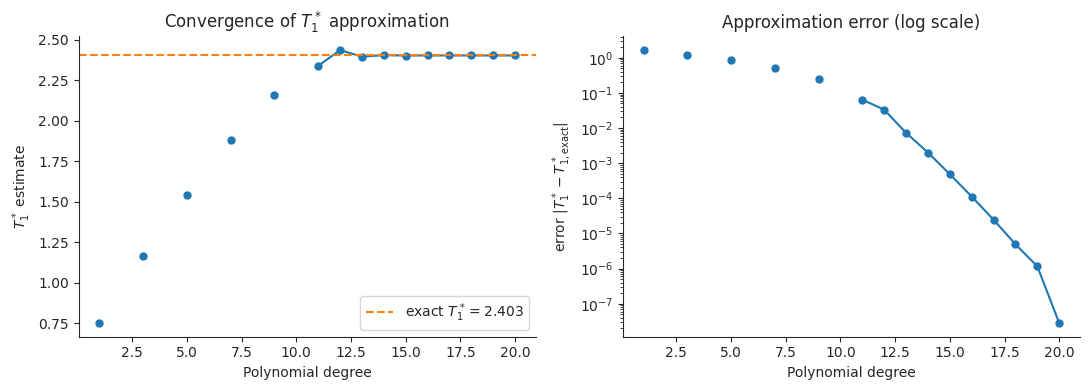

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from math import factorial

# ── Parameters ────────────────────────────────────────────────────────────────
disc_on_num = b2**2 - 4*a1*b1_on
lam1_num = (-b2 + np.sqrt(disc_on_num)) / 2
lam2_num = (-b2 - np.sqrt(disc_on_num)) / 2
dB0_on   = b2 * mu * (b1_on/b1 - 1)
K1_num   = dB0_on / (lam1_num - lam2_num)

# ── Exact T1* ─────────────────────────────────────────────────────────────────
def f_exact(T1):
    return -(K1_num/T1) * ((1 - np.exp(lam1_num*T1))/lam1_num
                           - (1 - np.exp(lam2_num*T1))/lam2_num)

T1_exact = minimize_scalar(f_exact, bounds=(0.01, 30), method='bounded').x

# ── Polynomial coefficient for T1^k in the optimality condition ───────────────
# Setting f'(T1)=0 and dividing by K1*(λ2-λ1) gives:
#   Σ_{k=0}^{N}  c_k * T1^k = 0
# where  c_k = (k+1) / (k+2)!  *  (λ2^{k+1} - λ1^{k+1}) / (λ2 - λ1)
#
# "degree d" approximation: polynomial of degree d, using k=0,...,d
# → matches prev cells: degree=1 ↔ "1st-order", degree=2 ↔ "2nd-order", etc.

def poly_coeff(k, l1, l2):
    """Coefficient of T1^k in the optimality polynomial."""
    return (k + 1) / factorial(k + 2) * (l2**(k+1) - l1**(k+1)) / (l2 - l1)

# ── Sweep over polynomial degree ──────────────────────────────────────────────
MAX_DEGREE = 20
T1_approx = []

for degree in range(1, MAX_DEGREE + 1):
    # coefficients c_0, c_1, ..., c_degree  (degree+1 terms)
    coeffs = [poly_coeff(k, lam1_num, lam2_num) for k in range(degree + 1)]
    # numpy.roots wants highest degree first
    roots = np.roots(coeffs[::-1])
    # pick the positive real root closest to the exact answer
    real_pos = [r.real for r in roots if abs(r.imag) < 1e-8 and r.real > 0]
    if real_pos:
        best = min(real_pos, key=lambda r: abs(r - T1_exact))
        T1_approx.append(best)
    else:
        T1_approx.append(np.nan)

degrees = np.arange(1, MAX_DEGREE + 1)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"Exact T1* = {T1_exact:.6f}\n")
print(f"{'Degree':>7}  {'T1* approx':>12}  {'|error|':>10}  {'note'}")
print("-" * 52)
for d, T1a in zip(degrees, T1_approx):
    if np.isnan(T1a):
        print(f"{d:>7}  {'—':>12}  {'—':>10}  no positive real root")
    else:
        print(f"{d:>7}  {T1a:>12.6f}  {abs(T1a - T1_exact):>10.2e}")

# ── Convergence plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(degrees, T1_approx, 'o-', lw=1.5, ms=5)
ax.axhline(T1_exact, color='C1', ls='--', lw=1.5, label=f'exact $T_1^*={T1_exact:.3f}$')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('$T_1^*$ estimate')
ax.set_title('Convergence of $T_1^*$ approximation')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

errors = np.array([abs(T1a - T1_exact) if not np.isnan(T1a) else np.nan
                   for T1a in T1_approx])
ax = axes[1]
ax.semilogy(degrees, errors, 'o-', lw=1.5, ms=5)
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('error $|T_1^* - T_{1,\mathrm{exact}}^*|$')
ax.set_title('Approximation error (log scale)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1550402/3797046877.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


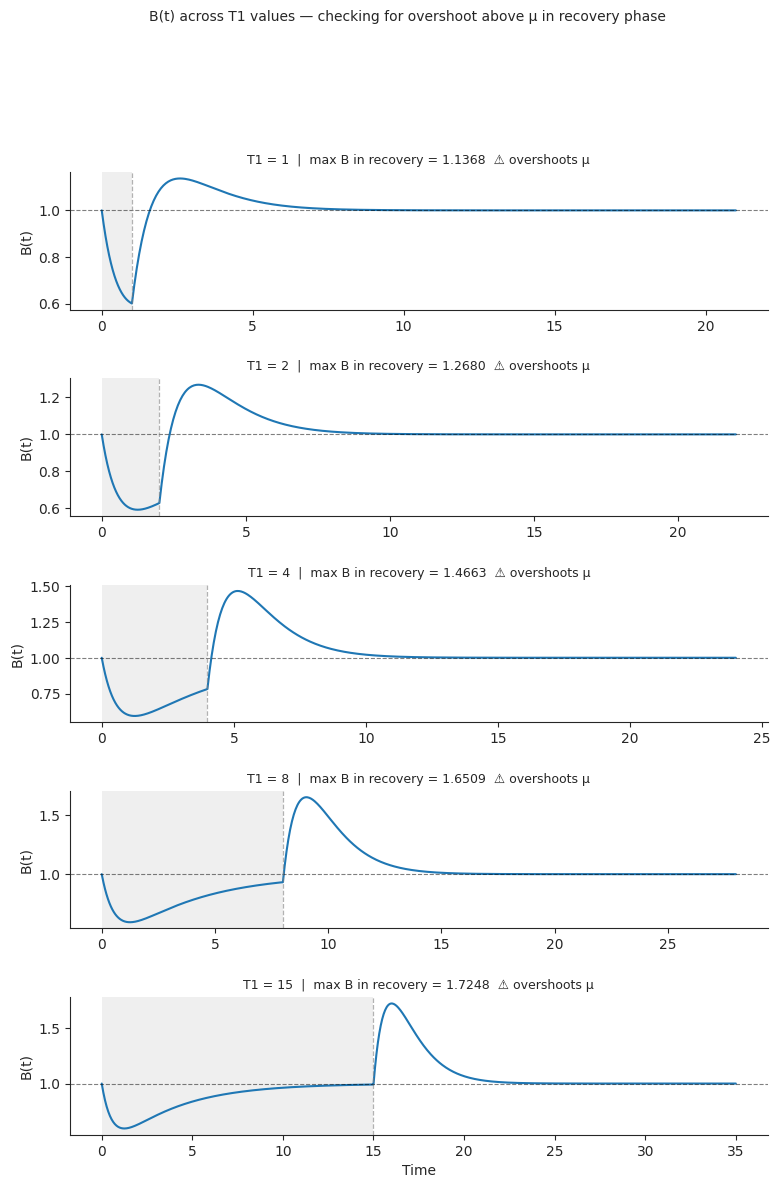

In [ ]:
# ======================================================================
# Does B overshoot mu during Phase 2 (recovery)?
# Test across a range of T1 values and check max(B) in recovery phase
# ======================================================================

T2 = 20.0   # long recovery window so we can see the full trajectory

T1_values = [1, 2, 4, 8, 15]
fig, axes = plt.subplots(len(T1_values), 1, figsize=(9, 2.5 * len(T1_values)),
                          sharex=False, gridspec_kw={'hspace': 0.5})

for ax, T1_test in zip(axes, T1_values):
    t1 = np.linspace(0, T1_test, 500)
    t2 = np.linspace(0, T2, 500)

    sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), [A_ss, B_ss, 1.0], t1)
    sol2 = odeint(lambda y, t: abc_rhs(t, y, b1),    sol1[-1],          t2)

    B1 = sol1[:, 1]
    B2 = sol2[:, 1]
    t_full_test = np.concatenate([t1, T1_test + t2[1:]])
    B_full_test = np.concatenate([B1, B2[1:]])

    ax.plot(t_full_test, B_full_test, color='C0', lw=1.5)
    ax.axhline(mu, color='k', ls='--', lw=0.8, alpha=0.5, label=f'μ = {mu}')
    ax.axvline(T1_test, color='gray', ls='--', lw=0.9, alpha=0.6)
    ax.axvspan(0, T1_test, color='lightgray', alpha=0.35, lw=0, zorder=0)

    B2_max = B2.max()
    overshoot = B2_max > mu + 1e-6
    ax.set_title(f'T1 = {T1_test}  |  max B in recovery = {B2_max:.4f}  '
                 f'{"⚠ overshoots μ" if overshoot else "✓ stays ≤ μ"}', fontsize=9)
    ax.set_ylabel('B(t)')
    clean_ax(ax)

axes[-1].set_xlabel('Time')
plt.suptitle('B(t) across T1 values — checking for overshoot above μ in recovery phase',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# Analytical J(T1) with fixed T2 from convergence criterion

Fix T2 based on the **off-treatment eigenvalue alone** (no dependence on T1):

$$T_2 = \frac{\ln(100)}{|\lambda_{off}|} \approx 4.6$$

This guarantees 99% decay of the exponential transient envelope during recovery. With T2 fixed, every cycle effectively resets to the off-treatment SS, so the multi-cycle average equals the single-cycle formula and J becomes a clean **single-variable** function of T1.

99% convergence to off-treatment SS at T2 = 7.124
(initial deviation = 1.2712, 1% threshold = 0.0127)
(note: ln(100) = 4.605 would have been wrong for this critically damped system)


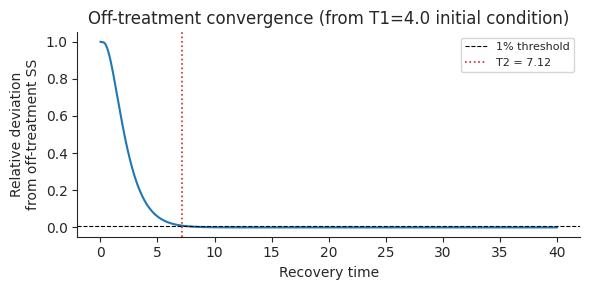

In [ ]:
# ── Compute T2 numerically: time for 99% convergence to off-treatment SS ──
# Use T1=4 as a representative on-treatment duration to get initial conditions
_T1_ref = 4.0
_t1 = np.linspace(0, _T1_ref, 400)
_sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), [A_ss, B_ss, 1.0], _t1)
_state_at_switch = _sol1[-1, :2]   # [A_end, B_end]

_dev0 = np.linalg.norm(_state_at_switch - np.array([A_ss, B_ss]))

_t2_long = np.linspace(0, 40, 2000)
_sol2 = odeint(lambda y, t: abc_rhs(t, y, b1),
               np.append(_state_at_switch, _sol1[-1, 2]), _t2_long)
_dev = np.linalg.norm(_sol2[:, :2] - np.array([A_ss, B_ss]), axis=1)

_idx = np.argmax(_dev < 0.01 * _dev0)
T2_fixed = _t2_long[_idx]
print(f"99% convergence to off-treatment SS at T2 = {T2_fixed:.3f}")
print(f"(initial deviation = {_dev0:.4f}, 1% threshold = {0.01*_dev0:.4f})")
print(f"(note: ln(100) = {np.log(100):.3f} would have been wrong for this critically damped system)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(_t2_long, _dev / _dev0, color='C0', lw=1.5)
ax.axhline(0.01, color='k', ls='--', lw=0.8, label='1% threshold')
ax.axvline(T2_fixed, color='C3', ls=':', lw=1.2, label=f'T2 = {T2_fixed:.2f}')
ax.set_xlabel('Recovery time')
ax.set_ylabel('Relative deviation\nfrom off-treatment SS')
ax.set_title(f'Off-treatment convergence (from T1={_T1_ref} initial condition)')
ax.legend(fontsize=8)
clean_ax(ax)
plt.tight_layout()
plt.show()

Analytical optimal T1 = 5.950,  J* = 0.12099


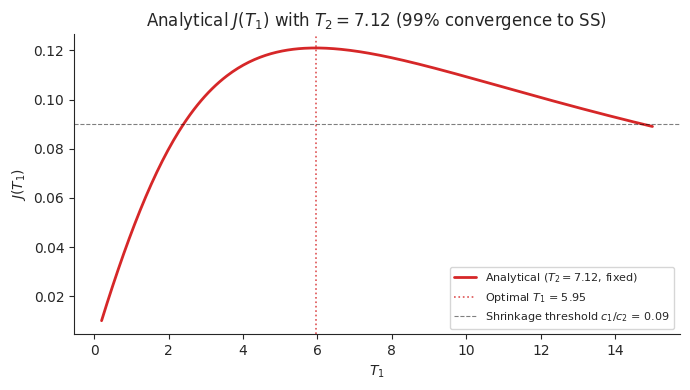

In [ ]:
from scipy.optimize import minimize_scalar

# ── On-treatment eigenvalues ──────────────────────────────────────────
disc_on = b2**2 - 4 * a1 * b1_on
lam1 = (-b2 + np.sqrt(disc_on)) / 2
lam2 = (-b2 - np.sqrt(disc_on)) / 2

# T2_fixed comes from the convergence cell above

# ── Analytical J(T1) with fixed T2 ────────────────────────────────────
def J_analytical(T1, T2):
    """Analytical shrinkage rate over one cycle starting from off-treatment SS."""
    v0 = b1_on * (b2 * mu / b1) - b2 * mu
    C  = v0 / (lam1 - lam2)
    I1 = -C * ((np.exp(lam1*T1) - 1)/lam1 - (np.exp(lam2*T1) - 1)/lam2)

    B_end    = C * (np.exp(lam1*T1) - np.exp(lam2*T1)) + mu
    Bdot_end = C * (lam1*np.exp(lam1*T1) - lam2*np.exp(lam2*T1))
    A_end    = (Bdot_end + b2 * B_end) / b1_on

    v_new = b1 * A_end - b2 * B_end
    K1 = B_end - mu
    K2 = v_new + K1

    tau_cross = (-K1 / K2) if (K2 > 1e-12 and K1 < 0) else np.inf
    t_int = min(T2, tau_cross)
    I2 = (K1 + K2 * (1 + t_int)) * np.exp(-t_int) - (K1 + K2)

    return (I1 + I2) / (T1 + T2)

# ── Optimize over T1 ─────────────────────────────────────────────────
res_ana = minimize_scalar(
    lambda T1: -J_analytical(T1, T2_fixed),
    bounds=(0.1, 20), method='bounded'
)
T1_ana_opt = res_ana.x
J_ana_opt  = -res_ana.fun
print(f"Analytical optimal T1 = {T1_ana_opt:.3f},  J* = {J_ana_opt:.5f}")

# ── Plot J(T1) ────────────────────────────────────────────────────────
T1_arr = np.linspace(0.2, 15, 300)
J_arr  = [J_analytical(T1, T2_fixed) for T1 in T1_arr]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T1_arr, J_arr, color='C3', lw=2, label=f'Analytical ($T_2={T2_fixed:.2f}$, fixed)')
ax.axvline(T1_ana_opt, color='C3', ls=':', lw=1.2, alpha=0.8,
           label=f'Optimal $T_1$ = {T1_ana_opt:.2f}')
ax.axhline(c1/c2, color='k', ls='--', lw=0.8, alpha=0.5,
           label=f'Shrinkage threshold $c_1/c_2$ = {c1/c2}')
ax.set_xlabel('$T_1$')
ax.set_ylabel('$J(T_1)$')
ax.set_title(f'Analytical $J(T_1)$ with $T_2={T2_fixed:.2f}$ (99% convergence to SS)')
ax.legend(fontsize=8)
clean_ax(ax)
plt.tight_layout()
plt.show()

Optimal T1 = 4.209,  T2 = 2.609,  J* = 0.15732


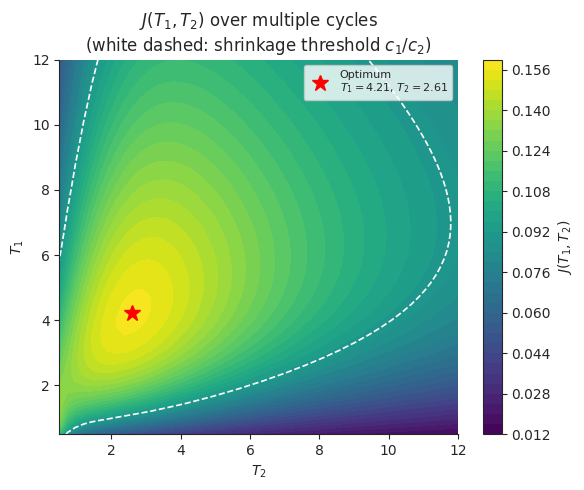

In [ ]:
from scipy.optimize import minimize

# ── Numerical multi-cycle objective ───────────────────────────────────
def J_multicycle(T1, T2, n_cycles=6):
    """Simulate n_cycles on/off cycles; return avg (mu-B)+ per unit time."""
    def rhs(y, t, b1_val):
        A, B, _, I = y
        return [a1*(mu - B), b1_val*A - b2*B, 0.0, max(mu - B, 0)]

    y_cur = [A_ss, B_ss, 1.0, 0.0]
    for _ in range(n_cycles):
        t_on  = np.linspace(0, T1, 200)
        y_cur = odeint(lambda y, t: rhs(y, t, b1_on), y_cur, t_on)[-1]
        t_off = np.linspace(0, T2, 200)
        y_cur = odeint(lambda y, t: rhs(y, t, b1),    y_cur, t_off)[-1]

    return y_cur[3] / (n_cycles * (T1 + T2))

# ── 2D heatmap ────────────────────────────────────────────────────────
T1_grid = np.linspace(0.5, 12, 50)
T2_grid = np.linspace(0.5, 12, 50)
J_grid  = np.array([[J_multicycle(t1, t2) for t2 in T2_grid] for t1 in T1_grid])

# ── Joint optimization ────────────────────────────────────────────────
res = minimize(
    lambda x: -J_multicycle(x[0], x[1]),
    x0=[3.0, 3.0],
    bounds=[(0.1, 20), (0.1, 20)],
    method='L-BFGS-B'
)
T1_opt, T2_opt = res.x
J_opt = -res.fun
print(f"Optimal T1 = {T1_opt:.3f},  T2 = {T2_opt:.3f},  J* = {J_opt:.5f}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(T2_grid, T1_grid, J_grid, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label='$J(T_1, T_2)$')
ax.contour(T2_grid, T1_grid, J_grid,
           levels=[c1/c2], colors='white', linewidths=1.2, linestyles='--')
ax.plot(T2_opt, T1_opt, 'r*', ms=12, label=f'Optimum\n$T_1={T1_opt:.2f}$, $T_2={T2_opt:.2f}$')
ax.set_xlabel('$T_2$')
ax.set_ylabel('$T_1$')
ax.set_title('$J(T_1, T_2)$ over multiple cycles\n(white dashed: shrinkage threshold $c_1/c_2$)')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()

T1 = 6.631,  T2 = 10.000,  cycle duration = 16.631


/tmp/ipykernel_1550402/3516432069.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


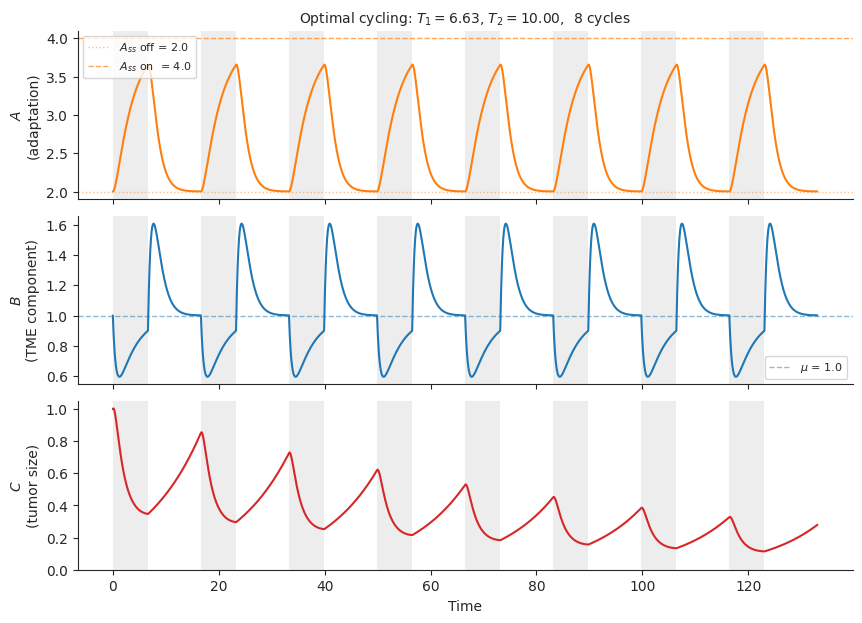

In [ ]:
# ======================================================================
# Multi-cycle simulation using jointly optimal T1 and T2
# ======================================================================

n_cycles = 8
T1_opt = 6.631
T2_opt = 10.0

print(f"T1 = {T1_opt:.3f},  T2 = {T2_opt:.3f},  cycle duration = {T1_opt + T2_opt:.3f}")

t_all, A_all, B_all, C_all = [], [], [], []
y_cur = [A_ss, B_ss, 1.0]
t_cur = 0.0

for i in range(n_cycles):
    # ON phase
    t_on = np.linspace(0, T1_opt, 300)
    s_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), y_cur, t_on)
    t_all.append(t_cur + t_on);  A_all.append(s_on[:,0]);  B_all.append(s_on[:,1]);  C_all.append(s_on[:,2])
    t_cur += T1_opt;  y_cur = s_on[-1]

    # OFF phase
    t_off = np.linspace(0, T2_opt, 300)
    s_off = odeint(lambda y, t: abc_rhs(t, y, b1), y_cur, t_off)
    t_all.append(t_cur + t_off);  A_all.append(s_off[:,0]);  B_all.append(s_off[:,1]);  C_all.append(s_off[:,2])
    t_cur += T2_opt;  y_cur = s_off[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, gridspec_kw={'hspace': 0.1})

for i in range(n_cycles):
    t_start = i * (T1_opt + T2_opt)
    for ax in axes:
        ax.axvspan(t_start, t_start + T1_opt, color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':',  lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(mu, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(
    f'Optimal cycling: $T_1={T1_opt:.2f}$, $T_2={T2_opt:.2f}$,  {n_cycles} cycles',
    fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_optimal_cycling.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar

# Define the constants
T2 = 10.0
lambda_1 = -1 + np.sqrt(2)/2
lambda_2 = -1 - np.sqrt(2)/2

def calculate_shrinkage_rate(T1):
    # 1. Calculate states at T1
    e_lam1_T1 = np.exp(lambda_1 * T1)
    e_lam2_T1 = np.exp(lambda_2 * T1)
    
    B1 = 1 - (1/np.sqrt(2)) * e_lam1_T1 + (1/np.sqrt(2)) * e_lam2_T1
    A1 = 4 - (np.sqrt(2) + 1) * e_lam1_T1 + (np.sqrt(2) - 1) * e_lam2_T1
    
    # 2. Prevent division by zero if T1 is exactly 0
    denominator = A1 - B1 - 1
    if denominator <= 0:
        return 0.0
        
    # 3. Calculate total integral using our analytical shortcut
    I_total = denominator * np.exp((B1 - 1) / denominator)
    
    # 4. Return the time-averaged rate (negative for minimization)
    rate = I_total / (T1 + T2)
    return -rate

# Optimize over a reasonable clinical window (e.g., 0.1 to 15 time units)
result = minimize_scalar(calculate_shrinkage_rate, bounds=(0.1, 15.0), method='bounded')

optimal_T1 = result.x
max_rate = -result.fun

print(f"Optimal Treatment Duration (T1): {optimal_T1:.3f}")
print(f"Maximum Time-Averaged Shrinkage Rate: {max_rate:.4f}")
print(f"Total Shrinkage Integral per Cycle: {max_rate * (optimal_T1 + T2):.4f}")

Optimal Treatment Duration (T1): 6.631
Maximum Time-Averaged Shrinkage Rate: 0.0996
Total Shrinkage Integral per Cycle: 1.6567
